
Assignment 8

Name: Rushi Gujarathi | Roll No. 17 | PRN no. 1252090017

Apply appropriate ML algorithm on a dataset collected in a cosmetics shop showing

details of customers to predict customer response for special offer. Create confusion matrix based on above data and find:
Accuracy
Precision
Recall
F-1 score

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

Read Dataset

In [ ]:
df = pd.read_csv("/content/bank-full.csv")

print("Original Shape:", df.shape)
print(df.head())
print(df.columns)

Original Shape: (45211, 1)
  age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0  58;"management";"married";"tertiary";"no";2143...                                                                                                  
1  44;"technician";"single";"secondary";"no";29;"...                                                                                                  
2  33;"entrepreneur";"married";"secondary";"no";2...                                                                                                  
3  47;"blue-collar";"married";"unknown";"no";1506...                                                                                                  
4  33;"unknown";"single";"unknown";"no";1;"no";"n...                                                                                                  
Index(['age;"job";"marital";"education";"default";"balance";"housin

Data Cleaning

In [ ]:
df = df.drop_duplicates()

df = df.dropna()

print("After Cleaning Shape:", df.shape)

After Cleaning Shape: (45211, 1)


Encode Target Variable

In [ ]:
import pandas as pd

# Load correctly
df = pd.read_csv("/content/bank-full.csv", sep=';')

print("Columns:", df.columns)

# Remove duplicates & null
df = df.drop_duplicates()
df = df.dropna()

# Convert target
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print("Target Classes:", df['y'].unique())

Columns: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')
Target Classes: [0 1]


Separate Features & Target

In [ ]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [ ]:
df['y'] = df['y'].astype('category').cat.codes

In [ ]:
X = df.drop("y", axis=1)
y = df["y"]

print("Unique classes:", y.unique())

Unique classes: [0 1]


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X = pd.get_dummies(X, drop_first=True)

Train Logistic Regression Model

In [ ]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Now split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Confusion Matrix and Evaluation Metrics

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[7757  195]
 [ 717  374]]
Accuracy: 0.8991485126617274
Precision: 0.6572934973637962
Recall: 0.34280476626947753
F1 Score: 0.4506024096385542


Plot Confusion Matrix

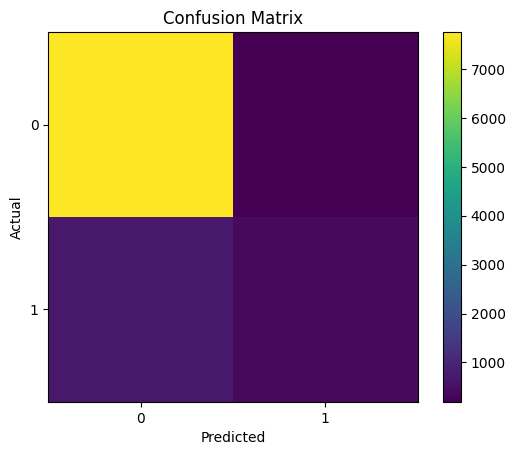

In [ ]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()